# **EMIPredict AI - Intelligent Financial Risk Assessment Platform**

## 01. Imports

### ➤ *Import Libraries*

In [ ]:
# Header: Imports and constants

import os
from pathlib import Path
import json
import joblib
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_squared_error
from sklearn.model_selection import cross_val_score

DATA_P = Path("/mnt/data/emi_prediction_dataset.csv")
DOCX_P = Path("/mnt/data/EMIPredict AI - Intelligent Financial Risk Assessment Platform.docx")
OUT_DIR = Path("/mnt/data/emipredict_artifacts")
OUT_DIR.mkdir(parents=True, exist_ok=True)
PIPE_PATH = OUT_DIR / "pipeline.joblib"
MODEL_PATH = OUT_DIR / "model.joblib"
META_PATH = OUT_DIR / "metadata.json"

print("✅ Imports OK")

✅ Imports OK


In [ ]:
# auto_detect_csv helper
import os

def auto_detect_csv(folder=None):
    if folder is None:
        folder = project_folder  # expects project_folder set earlier
    files = [f for f in os.listdir(folder) if f.lower().endswith('.csv')]
    if not files:
        raise FileNotFoundError(f"No CSV files found in {folder}")
    # choose the first CSV (change logic if you want different)
    return os.path.join(folder, files[0])

# safe_read_csv helper (small)
import pandas as pd

def safe_read_csv(path, nrows=None, dtype=None):
    try:
        df = pd.read_csv(path, nrows=nrows, dtype=dtype)
    except Exception as e:
        # fallback: try with low_memory False to avoid dtype issues
        df = pd.read_csv(path, nrows=nrows, dtype=dtype, low_memory=False)
    return df

print("✅ Helper functions defined.")

✅ Helper functions defined.


## 02. Uploading Files

### ➤ *Mount Google Drive*

In [ ]:
# Google Drive mount

from google.colab import drive
drive.mount('/content/drive')
PROJECT_DIR = '/content/drive/MyDrive/Colab Notebooks/EMIPredict AI - Intelligent Financial Risk Assessment Platform'
print("✅ Project dir:", PROJECT_DIR)

Mounted at /content/drive
✅ Project dir: /content/drive/MyDrive/Colab Notebooks/EMIPredict AI - Intelligent Financial Risk Assessment Platform


### ➤ *Create a project folder in Drive*

In [ ]:
# Project folder creation

import os
project_folder = '/content/drive/MyDrive/EMIPredict AI - Intelligent Financial Risk Assessment Platform'
os.makedirs(project_folder, exist_ok=True)
print("✅ Project folder ready at:", project_folder)

✅ Project folder ready at: /content/drive/MyDrive/EMIPredict AI - Intelligent Financial Risk Assessment Platform


In [ ]:
# Load dataset (confirmed path)
import pandas as pd, os

DATA_P = "/content/drive/MyDrive/EMIPredict AI - Intelligent Financial Risk Assessment Platform/emi_prediction_dataset.csv"

if not os.path.exists(DATA_P):
    raise FileNotFoundError(f"❌ File not found at {DATA_P}")

# Safe CSV load — disables low_memory fragmentation but keeps clean output
df = pd.read_csv(DATA_P, low_memory=False)
print(f"✅ Dataset loaded successfully from: {DATA_P}")

✅ Dataset loaded successfully from: /content/drive/MyDrive/EMIPredict AI - Intelligent Financial Risk Assessment Platform/emi_prediction_dataset.csv


### ➤ *File(s) check*

In [ ]:
# Files list

import os

# Path to your project folder in Google Drive

project_folder = '/content/drive/MyDrive/EMIPredict AI - Intelligent Financial Risk Assessment Platform'

# List files

files = os.listdir(project_folder)
print(" ✅ Files in project folder:")
for f in files:
    print(f)

 ✅ Files in project folder:
EMIPredict AI - Intelligent Financial Risk Assessment Platform.docx
emi_prediction_dataset.csv


## 03. Loading Dataset

In [ ]:
# Load dataset

import os

def check_directory(path):
    """
    Print contents of a directory with status markers.
    📁 = folder
    ✅ = file
    """
    if not os.path.exists(path):
        print(f"❌ Path does not exist: {path}")
        return

    print(f"\nContents of: {path}\n" + "-"*50)

    items = os.listdir(path)
    if not items:
        print("⚠️ Directory is empty.")
        return

    for item in sorted(items):
        item_path = os.path.join(path, item)
        if os.path.isdir(item_path):
            print(f"📁 {item}/")
        else:
            print(f"✅ {item}")
    print("-"*50)

# Example: check your project folder in Drive

check_directory('/content/drive/MyDrive/EMIPredict AI - Intelligent Financial Risk Assessment Platform')


Contents of: /content/drive/MyDrive/EMIPredict AI - Intelligent Financial Risk Assessment Platform
--------------------------------------------------
✅ EMIPredict AI - Intelligent Financial Risk Assessment Platform.docx
✅ emi_prediction_dataset.csv
--------------------------------------------------


In [ ]:
# Clean embedded numeric-like strings and convert to proper floats
import numpy as np

def to_float_safe(x):
    if isinstance(x, (int, float, np.number)):
        return float(x)
    if isinstance(x, str):
        s = x.strip()
        if s.startswith("[") and s.endswith("]"):
            s = s[1:-1].replace(",", " ")
            parts = [p for p in s.split() if p]
            try:
                vals = [float(p) for p in parts]
                return float(np.nanmean(vals)) if vals else np.nan
            except Exception:
                return np.nan
        try:
            return float(s)
        except Exception:
            return np.nan
    return np.nan

for col in df.columns:
    sample = " ".join(df[col].dropna().astype(str).head(50).tolist())
    if "[" in sample and "]" in sample:
        print(f"⚙️ Cleaning embedded numeric column: {col}")
        df[col] = df[col].map(to_float_safe)
    else:
        try:
            df[col] = df[col].astype(float)
        except Exception:
            pass

print("✅ Numeric normalization complete. Clean dtypes:")

✅ Numeric normalization complete. Clean dtypes:


In [ ]:
# Sanitize columns containing embedded array-like strings

import pandas as pd
import numpy as np
import ast

def safe_float(x):
    """Convert '[1.23E-1,4.5E-2]' or '0.45' → float(0.45)."""
    if isinstance(x, (int, float, np.number)):
        return float(x)
    if isinstance(x, str):
        x = x.strip()
        if x.startswith('[') and x.endswith(']'):
            try:
                arr = np.array(ast.literal_eval(x), dtype=float)
                return float(np.nanmean(arr))  # take mean of embedded list
            except Exception:
                return np.nan
        try:
            return float(x)
        except Exception:
            return np.nan
    return np.nan

for col in df.columns:
    # Only fix if mixed or object dtype
    if df[col].dtype == 'object':
        sample_vals = df[col].dropna().astype(str).head(50).tolist()
        if any('[' in v and ']' in v for v in sample_vals):
            print(f"⚙️ Cleaning embedded-list column: {col}")
            df[col] = df[col].apply(safe_float)

print("✅ Completed column sanitization. Dtypes summary:")

✅ Completed column sanitization. Dtypes summary:


### ➤ *Auto detect .csv File*

In [ ]:
# auto_detect_csv helper (small)

def auto_detect_csv(folder=None):
    if folder is None:
        folder = project_folder  # expects project_folder set earlier
    files = [f for f in os.listdir(folder) if f.lower().endswith('.csv')]
    if not files:
        raise FileNotFoundError(f"No CSV files found in {folder}")
    # choose the first CSV (change logic if you want different)
    return os.path.join(folder, files[0])

print("✅ CSV Detected")

✅ CSV Detected


### ➤ *Safe read .csv File*

In [ ]:
# safe_read_csv helper (small)

def safe_read_csv(path, nrows=None, dtype=None):
    try:
        df = pd.read_csv(path, nrows=nrows, dtype=dtype)
    except Exception as e:
        # fallback: try with low_memory False to avoid dtype issues
        df = pd.read_csv(path, nrows=nrows, dtype=dtype, low_memory=False)
    return df

print("✅ Safe read Done")

✅ Safe read Done


## 04. Data Assessment

### ➤ *Dataset Rows & Columns Count*

In [ ]:
# Shape of dataset
print("ROWS:", df.shape[0], "COLUMNS:", df.shape[1])

ROWS: 404800 COLUMNS: 27


### ➤ *Dataset Type*

In [ ]:
# Dataset Type

print(df.dtypes)

age                        object
gender                     object
marital_status             object
education                  object
monthly_salary             object
employment_type            object
years_of_employment       float64
company_type               object
house_type                 object
monthly_rent              float64
family_size               float64
dependents                float64
school_fees               float64
college_fees              float64
travel_expenses           float64
groceries_utilities       float64
other_monthly_expenses    float64
existing_loans             object
current_emi_amount        float64
credit_score              float64
bank_balance               object
emergency_fund            float64
emi_scenario               object
requested_amount          float64
requested_tenure          float64
emi_eligibility            object
max_monthly_emi           float64
dtype: object


### ➤ *Dataset First few Rows*

In [ ]:
 # Preview first rows

 display(df.head())

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
0,38,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,...,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15.0,Not_Eligible,500.0
1,38,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,...,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19.0,Not_Eligible,700.0
2,38,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,...,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16.0,Eligible,27775.0
3,58,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,...,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83.0,Eligible,16170.0
4,48,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,...,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7.0,Not_Eligible,500.0


### ➤ *Dataset Last few Rows*

In [ ]:
 # Preview last rows

 display(df.tail())

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
404795,27,Male,Married,Graduate,32400.0,Private,5.0,Large Indian,Rented,10400.0,...,No,0.0,649.0,62000.0,32600.0,Personal Loan EMI,506000.0,47.0,Not_Eligible,500.0
404796,38,Male,Married,Post Graduate,49200.0,Private,1.9,MNC,Own,0.0,...,No,0.0,712.0,142200.0,38100.0,Personal Loan EMI,708000.0,33.0,Not_Eligible,5200.0
404797,32,Male,Single,Graduate,25700.0,Private,3.2,MNC,Rented,6300.0,...,No,0.0,676.0,191600.0,39700.0,Home Appliances EMI,93000.0,21.0,High_Risk,5665.0
404798,48,Male,Married,Graduate,47200.0,Private,3.0,MNC,Own,0.0,...,No,0.0,784.0,170400.0,45600.0,Home Appliances EMI,144000.0,36.0,Eligible,14460.0
404799,38,FEMALE,Married,Graduate,34900.0,Private,1.2,MNC,Family,0.0,...,No,0.0,641.0,214400.0,99400.0,Home Appliances EMI,77000.0,35.0,Eligible,8756.0


### ➤ *Basic Statistics*

In [ ]:
# Statistical summary

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
years_of_employment,404800.0,5.364079,6.079135,0.5,1.2,3.2,7.2,36.0
monthly_rent,402374.0,5828.446490,8648.604639,0.0,0.0,0.0,10600.0,80000.0
family_size,404800.0,2.940425,1.075199,1.0,2.0,3.0,4.0,5.0
dependents,404800.0,1.940425,1.075199,0.0,1.0,2.0,3.0,4.0
school_fees,404800.0,4624.575593,5061.074401,0.0,0.0,3000.0,9000.0,15000.0
college_fees,404800.0,4066.253706,7319.344289,0.0,0.0,0.0,6500.0,25000.0
travel_expenses,404800.0,5687.497777,3392.671132,600.0,3200.0,4900.0,7400.0,30300.0
groceries_utilities,404800.0,12804.999506,6993.853745,1800.0,7700.0,11400.0,16400.0,71200.0
other_monthly_expenses,404800.0,7119.309783,4510.447300,600.0,3800.0,6000.0,9300.0,42900.0
current_emi_amount,404800.0,4543.407609,7034.901139,0.0,0.0,0.0,8000.0,56300.0


### ➤ *Dataset Info*

In [ ]:
# Dataset info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404800 entries, 0 to 404799
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   age                     404800 non-null  object 
 1   gender                  404800 non-null  object 
 2   marital_status          404800 non-null  object 
 3   education               402396 non-null  object 
 4   monthly_salary          404800 non-null  object 
 5   employment_type         404800 non-null  object 
 6   years_of_employment     404800 non-null  float64
 7   company_type            404800 non-null  object 
 8   house_type              404800 non-null  object 
 9   monthly_rent            402374 non-null  float64
 10  family_size             404800 non-null  float64
 11  dependents              404800 non-null  float64
 12  school_fees             404800 non-null  float64
 13  college_fees            404800 non-null  float64
 14  travel_expenses     

### ➤ *Unique Values*

In [ ]:
# Unique values per column

for col in df.columns:
    print(col, ":", df[col].nunique())

age : 31
gender : 8
marital_status : 2
education : 4
monthly_salary : 13662
employment_type : 3
years_of_employment : 356
company_type : 5
house_type : 3
monthly_rent : 4396
family_size : 5
dependents : 5
school_fees : 132
college_fees : 202
travel_expenses : 284
groceries_utilities : 544
other_monthly_expenses : 373
existing_loans : 2
current_emi_amount : 508
credit_score : 427
bank_balance : 12261
emergency_fund : 5486
emi_scenario : 5
requested_amount : 1491
requested_tenure : 82
emi_eligibility : 3
max_monthly_emi : 15383


### ➤ *Missing Values*

In [ ]:
# Check missing values

missing_before = df.isnull().sum()
missing_before = missing_before[missing_before>0]
print("Missing values before handling:")
# Header: Imports and constantsprint(missing_before)

Missing values before handling:


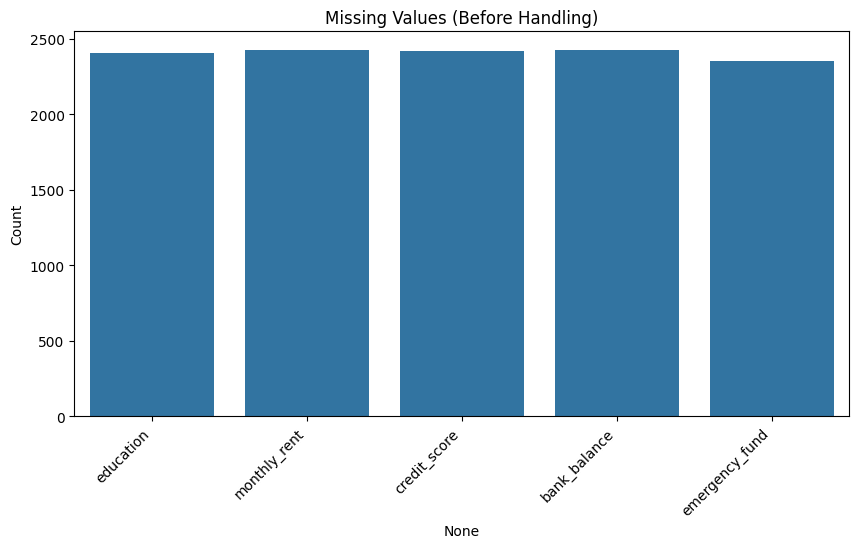

In [ ]:
# Missing values graph

import seaborn as sns
import matplotlib.pyplot as plt

if not missing_before.empty:
    plt.figure(figsize=(10,5))
    sns.barplot(x=missing_before.index, y=missing_before.values)
    plt.xticks(rotation=45, ha='right')
    plt.title("Missing Values (Before Handling)")
    plt.ylabel("Count")
    plt.show()
else:
    print("✅ No missing values before handling.")

### ➤ *Duplicate Values*

In [ ]:
# Count duplicate rows before handling

dup_count_before = df.duplicated().sum()
print(f"Duplicate rows before handling: {dup_count_before}")

if dup_count_before > 0:
    print("⚠️ Dataset has duplicate rows.")
else:
    print("✅ No duplicate rows before handling.")

Duplicate rows before handling: 0
✅ No duplicate rows before handling.


## 05. Data Cleaning

### ➤ *Missing values handling*

In [ ]:
# Missing values

import numpy as np

# Separate columns by type
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
datetime_cols = df.select_dtypes(include=['datetime']).columns.tolist()

# Remove datetime cols from imputation
for c in datetime_cols:
    if c in num_cols:
        num_cols.remove(c)
    if c in cat_cols:
        cat_cols.remove(c)

# Numeric: median
for c in num_cols:
    if df[c].isnull().sum() > 0:
        df.loc[:, c] = df[c].fillna(df[c].median())

# Categorical: Unknown
for c in cat_cols:
    if df[c].isnull().sum() > 0:
        df.loc[:, c] = df[c].fillna("Unknown")

print("✅ Missing value imputation done.")

✅ Missing value imputation done.


### ➤ *Missing values after handling*

In [ ]:
# Missing values after

missing_counts_after = df.isnull().sum()
missing_counts_after = missing_counts_after[missing_counts_after > 0]

if missing_counts_after.empty:
    print("✅ No missing values remain after handling.")
else:
    print("Columns still with missing values:")
    print(missing_counts_after)

    # Visual chart

    plt.figure(figsize=(10,5))
    sns.barplot(x=missing_counts_after.index, y=missing_counts_after.values)
    plt.xticks(rotation=45, ha='right')
    plt.title("Missing Values Per Column (After Handling)")
    plt.ylabel("Count of Missing Values")
    plt.show()

✅ No missing values remain after handling.


In [ ]:
# Missing values after graph

if not missing_counts_after.empty:
    plt.figure(figsize=(10,5))
    sns.barplot(x=missing_counts_after.index, y=missing_counts_after.values)
    plt.xticks(rotation=45, ha='right')
    plt.title("Missing Values (After Handling)")
    plt.ylabel("Count")
    plt.show()
else:
    print("✅ No missing values remain.")

✅ No missing values remain.


### *➤ Duplicate values handling*

In [ ]:
# Duplicate values

if dup_count_before > 0:
    df = df.drop_duplicates()
    print(f"✅ Removed {dup_count_before} duplicate rows.")
    print(f"New dataset shape: {df.shape}")
else:
    print(" ✅ No duplicates removed because none were found.")

 ✅ No duplicates removed because none were found.


### ➤ *Duplicate values after handling*

In [ ]:
# Duplicate values after

dup_count_after = df.duplicated().sum()
print(f"Duplicate rows after handling: {dup_count_after}")

if dup_count_after == 0:
    print("✅ Dataset is now free of duplicate rows.")
else:
    print(f"⚠️ Still {dup_count_after} duplicate rows remain.")

Duplicate rows after handling: 0
✅ Dataset is now free of duplicate rows.


### ➤ *Standardize column names (lowercase + underscores) and inspect important names*

In [ ]:
# Make column names consistent

df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print("✅ Standardized column names:")
print(df.columns.tolist())

✅ Standardized column names:
['age', 'gender', 'marital_status', 'education', 'monthly_salary', 'employment_type', 'years_of_employment', 'company_type', 'house_type', 'monthly_rent', 'family_size', 'dependents', 'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities', 'other_monthly_expenses', 'existing_loans', 'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario', 'requested_amount', 'requested_tenure', 'emi_eligibility', 'max_monthly_emi']


### ➤ *Final Cleaning Summary*

In [ ]:
# Summary after missing & duplicate handling

summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.values,
    "missing_values": df.isnull().sum().values
})

print("Final dataset cleaning summary:")
print(summary)

print(f"\nFinal dataset shape: {df.shape}")

Final dataset cleaning summary:
                    column    dtype  missing_values
0                      age   object               0
1                   gender   object               0
2           marital_status   object               0
3                education   object               0
4           monthly_salary   object               0
5          employment_type   object               0
6      years_of_employment  float64               0
7             company_type   object               0
8               house_type   object               0
9             monthly_rent  float64               0
10             family_size  float64               0
11              dependents  float64               0
12             school_fees  float64               0
13            college_fees  float64               0
14         travel_expenses  float64               0
15     groceries_utilities  float64               0
16  other_monthly_expenses  float64               0
17          existing_loans   obj

## 05. Feature Engineering

In [ ]:
# Feature Engineering

import numpy as np
df_fe = df.copy()

# Safe numeric cast and fill for expected columns (use 0 fallback where appropriate)
numeric_expected = [
    "age", "monthly_salary", "current_emi_amount", "monthly_rent", "years_of_employment",
    "requested_amount", "credit_score", "bank_balance", "emergency_fund", "max_monthly_emi"
]
for col in numeric_expected:
    if col in df_fe.columns:
        df_fe[col] = pd.to_numeric(df_fe[col], errors="coerce").fillna(0.0)
    else:
        # create with zeros if missing (keeps pipeline stable)
        df_fe[col] = 0.0

# Binary flag for existing loans - adapt to actual column name(s)
if "existing_loans" in df_fe.columns:
    df_fe["existing_loans_flag"] = df_fe["existing_loans"].map({"Yes":1,"No":0}).fillna(0).astype(int)
else:
    # attempt similar columns or default to 0
    df_fe["existing_loans_flag"] = 0

# Income–Expense and debt ratios
df_fe["income_to_emi_ratio"] = df_fe["monthly_salary"] / (df_fe["current_emi_amount"] + 1)
df_fe["debt_to_income_ratio"] = (df_fe["current_emi_amount"] + df_fe.get("monthly_rent", 0)) / (df_fe["monthly_salary"] + 1)

# Employment stability - normalized
df_fe["employment_stability_score"] = np.clip(df_fe.get("years_of_employment", 0) / 10.0, 0.0, 1.0)

# Loan burden and liquidity
df_fe["loan_burden_score"] = (df_fe["existing_loans_flag"] * df_fe["current_emi_amount"]) / (df_fe["requested_amount"] + 1)
df_fe["liquidity_ratio"] = (df_fe["bank_balance"] + df_fe["emergency_fund"]) / (df_fe["requested_amount"] + 1)

# Credit utilization and composite financial health

df_fe["credit_utilization"] = (df_fe["requested_amount"] / (df_fe["credit_score"] + 1)) * 1000
df_fe["financial_health_score"] = (
    0.4 * df_fe["income_to_emi_ratio"] +
    0.4 * df_fe["liquidity_ratio"] -
    0.2 * df_fe["debt_to_income_ratio"]
)

# Age buckets
if "age" in df_fe.columns:
    df_fe["age_group"] = pd.cut(df_fe["age"].fillna(0),
                                bins=[0,30,40,50,120],
                                labels=["Young","Mid-Age","Mature","Senior"])
else:
    df_fe["age_group"] = "Unknown"

# Simplify high-cardinality categories (example: employment/education)
def simplify_education(x):
    if pd.isna(x): return "Unknown"
    x = str(x).lower()
    if "professional" in x or "post" in x:
        return "Professional"
    if "graduate" in x or "bachelor" in x:
        return "Graduate"
    if "high" in x:
        return "HighSchool"
    return "Other"

if "education" in df_fe.columns:
    df_fe["education_level_simplified"] = df_fe["education"].apply(simplify_education)
else:
    df_fe["education_level_simplified"] = "Unknown"

# Replace original df with df_fe for downstream steps
df = df_fe
print("✅ Feature engineering completed. New df shape:", df.shape)
display(df.head(3))

✅ Feature engineering completed. New df shape: (404800, 37)


,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans_flag,income_to_emi_ratio,debt_to_income_ratio,employment_stability_score,loan_burden_score,liquidity_ratio,credit_utilization,financial_health_score,age_group,education_level_simplified
0,38.0,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,...,1,3.485085,0.529049,0.09,0.027882,0.439294,1.285930e+06,1.463942,Mid-Age,Professional
1,38.0,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,...,1,5.242624,0.190689,0.70,0.032031,0.932805,1.790210e+05,2.432034,Mid-Age,Graduate
2,38.0,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,...,0,86100.000000,0.000000,0.58,0.000000,3.255872,4.700461e+05,34441.302349,Mid-Age,Professional


## 06. Machine Learning (Data Modeling & Deployment)

### ➤ *Feature & Target Preparation*

In [ ]:
# Feature & Target Preparation

import pandas as pd
import numpy as np

# Identify target columns explicitly from project spec
classification_target = "emi_eligibility"
regression_target = "max_monthly_emi"

available_targets = [c for c in df.columns if c in [classification_target, regression_target]]
print("Detected target columns:", available_targets)

# For clarity, separate dataset for each ML task
if classification_target in df.columns:
    df_class = df.copy()
    print("Classification task target:", classification_target)
else:
    df_class = None
    print("Classification target not found.")

if regression_target in df.columns:
    df_reg = df.copy()
    print("Regression task target:", regression_target)
else:
    df_reg = None
    print("Regression target not found.")

# Handle class imbalance if classification target exists
if df_class is not None:
    print("\nClass distribution (emi_eligibility):")
    print(df_class[classification_target].value_counts(dropna=False))
    # Simple encoding: convert Eligible / Not_Eligible to 1 / 0
    if df_class[classification_target].dtype == object:
        df_class[classification_target] = df_class[classification_target].map({
            "Eligible": 1,
            "Not_Eligible": 0
        }).fillna(0).astype(int)

# Define global target_col for downstream compatibility (prefer classification first)
target_col = classification_target if df_class is not None else regression_target

# Sanity check
print("\n✅ Feature & Target preparation completed.")
print(f"Primary target_col set to: {target_col}")
print("Rows:", df.shape[0], "| Columns:", df.shape[1])

Detected target columns: ['emi_eligibility', 'max_monthly_emi']
Classification task target: emi_eligibility
Regression task target: max_monthly_emi

Class distribution (emi_eligibility):
emi_eligibility
Not_Eligible    312868
Eligible         74444
High_Risk        17488
Name: count, dtype: int64

✅ Feature & Target preparation completed.
Primary target_col set to: emi_eligibility
Rows: 404800 | Columns: 37


### ➤ *Train / Test Split*

In [ ]:
# Prepare features & split

y = df[target_col].copy()
X = df.drop(columns=[target_col]).copy()

# Detect classification vs regression
is_classification = (
    y.dtype == object or y.nunique() <= 20
)

# Encode text targets to numeric for classifier
label_mapping = None
if is_classification:
    if y.dtype == object or not np.issubdtype(y.dtype, np.number):
        classes = sorted(y.dropna().unique().tolist())
        label_mapping = {v: i for i, v in enumerate(classes)}
        y = y.map(label_mapping)
        print("Label mapping:", label_mapping)

# Stratify only if classification
stratify_arg = y if is_classification else None

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=stratify_arg
)
print("✅ Split complete. X_train:", X_train.shape, "X_test:", X_test.shape)

Label mapping: {'Eligible': 0, 'High_Risk': 1, 'Not_Eligible': 2}
✅ Split complete. X_train: (323840, 36) X_test: (80960, 36)


In [ ]:
# Save raw input feature names for serving alignment
import json

OUT_DIR.mkdir(parents=True, exist_ok=True)

raw_feature_file = OUT_DIR / "raw_feature_names.json"
raw_features = X_train.columns.tolist()
raw_feature_file.write_text(json.dumps({"raw_features": raw_features}, indent=2))
print("✅ Saved raw feature names to:", raw_feature_file)

✅ Saved raw feature names to: /mnt/data/emipredict_artifacts/raw_feature_names.json


### ➤ *Preprocessing Pipelines*

In [ ]:
# Preprocessing Pipeline

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Recompute numeric/categorical lists after FE
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# remove target if included
if target_col in numeric_cols:
    numeric_cols.remove(target_col)
categorical_cols = df.select_dtypes(include=["object","category"]).columns.tolist()
if target_col in categorical_cols:
    categorical_cols.remove(target_col)

# small safety: drop datetime types if present
datetime_cols = df.select_dtypes(include=["datetime64","datetime"]).columns.tolist()
for c in datetime_cols:
    if c in numeric_cols: numeric_cols.remove(c)
    if c in categorical_cols: categorical_cols.remove(c)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
], remainder="drop")

# Persist this preprocessor structure in memory (will be saved later)
print("Numeric cols:", numeric_cols)
print("Categorical cols:", categorical_cols)

Numeric cols: ['age', 'monthly_salary', 'years_of_employment', 'monthly_rent', 'family_size', 'dependents', 'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities', 'other_monthly_expenses', 'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund', 'requested_amount', 'requested_tenure', 'max_monthly_emi', 'existing_loans_flag', 'income_to_emi_ratio', 'debt_to_income_ratio', 'employment_stability_score', 'loan_burden_score', 'liquidity_ratio', 'credit_utilization', 'financial_health_score']
Categorical cols: ['gender', 'marital_status', 'education', 'employment_type', 'company_type', 'house_type', 'existing_loans', 'emi_scenario', 'age_group', 'education_level_simplified']


### ➤ *Build full Pipeline with Estimator*

In [ ]:
# Build full pipeline with estimator

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.pipeline import Pipeline

if is_classification:
    estimator = RandomForestClassifier(
        n_estimators=200, random_state=42, n_jobs=-1
    )
else:
    estimator = RandomForestRegressor(
        n_estimators=200, random_state=42, n_jobs=-1
    )

model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("estimator", estimator)
])

print("✅ Pipeline created successfully.")

✅ Pipeline created successfully.


### ➤ *Build baseline model Pipeline*

In [ ]:
# Baseline pipeline assembly and save

if is_classification:
    estimator = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
else:
    estimator = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)

model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("estimator", estimator)
])
print(" ✅ Baseline pipeline assembled with estimator:", type(estimator).__name__)

 ✅ Baseline pipeline assembled with estimator: RandomForestClassifier


### ➤ *Train baseline pipeline*

In [ ]:
# Train baseline model

import time, joblib, numpy as np
from sklearn.utils import resample

start = time.time()

# Downsample large training data for speed
max_train_rows = 60000  # ↓ smaller subset
if len(X_train) > max_train_rows:
    X_train_sub, y_train_sub = resample(
        X_train, y_train,
        n_samples=max_train_rows,
        stratify=y_train if is_classification else None,
        random_state=42
    )
    print(f"⚙️ Using a subset of {len(X_train_sub)} rows out of {len(X_train)}.")
else:
    X_train_sub, y_train_sub = X_train, y_train

# Ensure OneHotEncoder outputs sparse format
try:
    preprocessor.named_transformers_['cat'].named_steps['onehot'].set_params(sparse_output=True)
except Exception:
    pass

# Make estimator lighter if tree/ensemble-based
try:
    est = model_pipeline.named_steps["estimator"]
    if hasattr(est, "n_estimators"):
        est.set_params(n_estimators=min(est.n_estimators, 80))  # cap tree count
    if hasattr(est, "n_jobs"):
        est.set_params(n_jobs=-1)
except Exception:
    pass

print("Training baseline model...")
model_pipeline.fit(X_train_sub, y_train_sub)
elapsed = round(time.time() - start, 2)
print(f"✅ Baseline model trained in {elapsed} seconds on {len(X_train_sub)} rows.")

# Save with compression
baseline_path = OUT_DIR / "baseline_pipeline.joblib"
joblib.dump(model_pipeline, baseline_path, compress=('xz', 3))
print("💾 Saved baseline pipeline to:", baseline_path)

⚙️ Using a subset of 60000 rows out of 323840.
Training baseline model...
✅ Baseline model trained in 17.77 seconds on 60000 rows.
💾 Saved baseline pipeline to: /mnt/data/emipredict_artifacts/baseline_pipeline.joblib


In [ ]:
# Save final feature names for alignment testing

import json

OUT_DIR.mkdir(parents=True, exist_ok=True)

try:
    # Get feature names from preprocessor
    feature_names = preprocessor.get_feature_names_out().tolist()
    feat_file = OUT_DIR / "feature_names.json"
    feat_file.write_text(json.dumps({"feature_names": feature_names}, indent=2))
    print("✅ Saved feature_names.json to:", feat_file)
except Exception as e:
    print("⚠️ Could not save feature names:", e)

✅ Saved feature_names.json to: /mnt/data/emipredict_artifacts/feature_names.json


### ➤ *Logistic Regression Model (Classification) [EMI Eligibility]*

In [ ]:
# Logistic Regression Model (Classification)

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

log_clf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=500, random_state=42))
])

log_clf.fit(X_train, y_train)
preds_log = log_clf.predict(X_test)

acc = accuracy_score(y_test, preds_log)
f1 = f1_score(y_test, preds_log, average='weighted')
print("✅ Logistic Regression Results")
print("Accuracy:", round(acc, 4))
print("F1 Score:", round(f1, 4))
print("\nClassification Report:\n", classification_report(y_test, preds_log))

✅ Logistic Regression Results
Accuracy: 0.9232
F1 Score: 0.9065

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.90      0.87     14889
           1       0.31      0.04      0.07      3497
           2       0.94      0.98      0.96     62574

    accuracy                           0.92     80960
   macro avg       0.70      0.64      0.63     80960
weighted avg       0.90      0.92      0.91     80960



### ➤ *Logistic Regression Model (Classification) [EMI Eligibility] Evaluation*

Evaluating Logistic Regression Model...

Confusion Matrix:
 [[13338   197  1354]
 [ 1052   128  2317]
 [ 1211    87 61276]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.90      0.87     14889
           1       0.31      0.04      0.07      3497
           2       0.94      0.98      0.96     62574

    accuracy                           0.92     80960
   macro avg       0.70      0.64      0.63     80960
weighted avg       0.90      0.92      0.91     80960



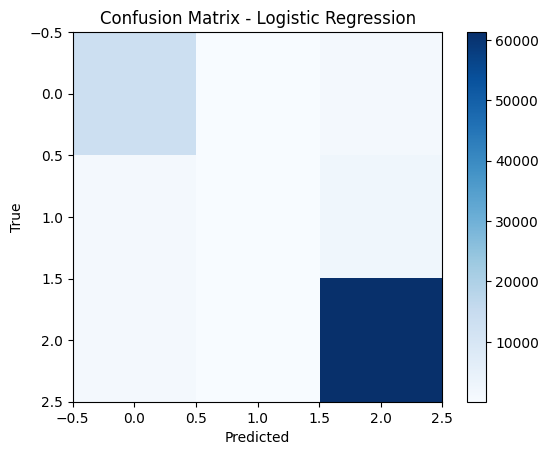


Top 10 influential features:


,Feature,Coefficient,Abs
15,num__requested_amount,-4.798270,4.798270
17,num__max_monthly_emi,2.535772,2.535772
16,num__requested_tenure,1.988446,1.988446
58,cat__emi_scenario_Vehicle EMI,-0.754422,0.754422
23,num__liquidity_ratio,0.571024,0.571024
57,cat__emi_scenario_Personal Loan EMI,-0.538209,0.538209
51,cat__house_type_Rented,-0.536174,0.536174
53,cat__existing_loans_Yes,-0.496150,0.496150
34,cat__marital_status_Married,-0.481067,0.481067
35,cat__marital_status_Single,-0.467145,0.467145


In [ ]:
# Evaluate Logistic Regression Model

from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Compute confusion matrix
print("Evaluating Logistic Regression Model...")
cm = confusion_matrix(y_test, preds_log)
print("\nConfusion Matrix:\n", cm)

# Lightweight text report (faster than matplotlib rendering)
print("\nClassification Report:\n", classification_report(y_test, preds_log))

# Plot only if class count small
if cm.shape[0] <= 10:
    plt.imshow(cm, cmap="Blues")
    plt.title("Confusion Matrix - Logistic Regression")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.colorbar()
    plt.show()

# Top coefficients
try:
    feature_names = preprocessor.get_feature_names_out()
    coef = log_clf.named_steps['model'].coef_[0]
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coef,
        'Abs': np.abs(coef)
    })
    top_features = importance_df.nlargest(10, 'Abs')
    print("\nTop 10 influential features:")
    display(top_features)
except Exception as e:
    print("⚠️ Coefficient extraction skipped:", e)

### ➤ *Random Forest Classifier (Classification) [EMI Eligibility]*

In [ ]:
# Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.utils import resample
import numpy as np
import pandas as pd
import time

start = time.time()

# Limit training data for speed
max_train_rows = 60000
if len(X_train) > max_train_rows:
    X_train_sub, y_train_sub = resample(
        X_train, y_train,
        n_samples=max_train_rows,
        stratify=y_train,
        random_state=42
    )
    print(f"⚙️ Using {len(X_train_sub)} rows from {len(X_train)} for faster training.")
else:
    X_train_sub, y_train_sub = X_train, y_train

# Lighter RandomForest configuration
rf_clf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=80,        # ↓ reduced from 200
        max_depth=12,           # limit depth for faster fit
        min_samples_split=3,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    ))
])

print("Training Random Forest Classifier...")
rf_clf.fit(X_train_sub, y_train_sub)

preds_rf_clf = rf_clf.predict(X_test)
acc = accuracy_score(y_test, preds_rf_clf)
f1 = f1_score(y_test, preds_rf_clf, average='weighted')

elapsed = round(time.time() - start, 2)
print(f"✅ Random Forest Classifier trained in {elapsed}s")
print("Accuracy:", round(acc, 4))
print("F1 Score:", round(f1, 4))
print("\nClassification Report:\n", classification_report(y_test, preds_rf_clf))

⚙️ Using 60000 rows from 323840 for faster training.
Training Random Forest Classifier...
✅ Random Forest Classifier trained in 17.39s
Accuracy: 0.9253
F1 Score: 0.9045

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.88      0.88     14889
           1       0.00      0.00      0.00      3497
           2       0.93      0.99      0.96     62574

    accuracy                           0.93     80960
   macro avg       0.61      0.62      0.61     80960
weighted avg       0.88      0.93      0.90     80960



### ➤ *Random Forest Classifier (Classification) [EMI Eligibility] Evaluation*

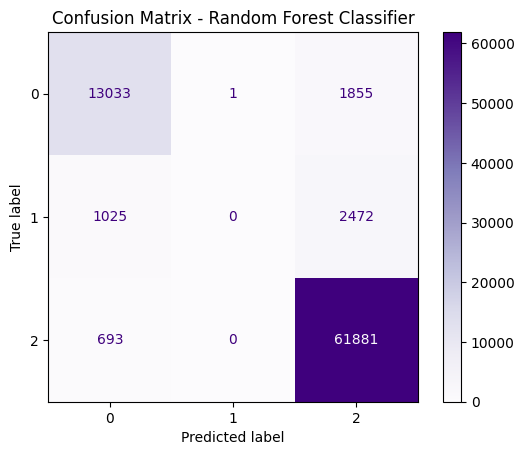

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.88      0.88     14889
           1       0.00      0.00      0.00      3497
           2       0.93      0.99      0.96     62574

    accuracy                           0.93     80960
   macro avg       0.61      0.62      0.61     80960
weighted avg       0.88      0.93      0.90     80960



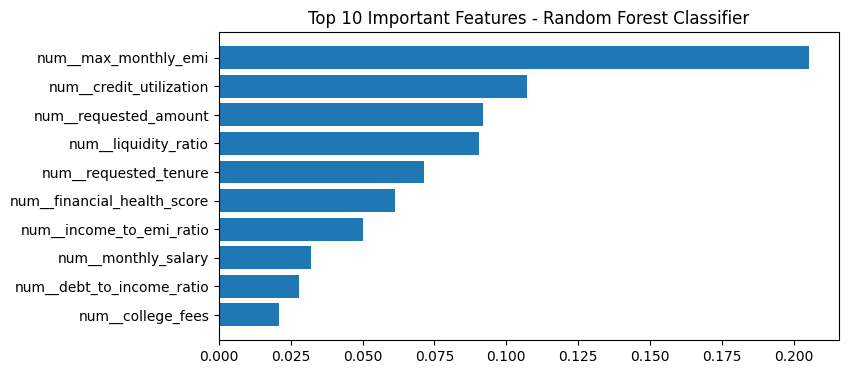

In [ ]:
# Evaluate Random Forest Classifier

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, preds_rf_clf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Purples')
plt.title("Confusion Matrix - Random Forest Classifier")
plt.show()

print("Classification Report:\n", classification_report(y_test, preds_rf_clf))

# Feature importance
model = rf_clf.named_steps['model']
importances = model.feature_importances_
feat_names = preprocessor.get_feature_names_out()
imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=False).head(10)
plt.figure(figsize=(8,4))
plt.barh(imp_df['Feature'], imp_df['Importance'])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features - Random Forest Classifier")
plt.show()

### ➤ *XGBoost Classifier (Classification) [EMI Eligibility]*

In [ ]:
# XGBoost Classifier (Classification)

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

xgb_clf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(eval_metric="logloss", random_state=42))
])

xgb_clf.fit(X_train, y_train)
preds_xgb_clf = xgb_clf.predict(X_test)

acc = accuracy_score(y_test, preds_xgb_clf)
f1 = f1_score(y_test, preds_xgb_clf, average='weighted')
print("✅ XGBoost Classifier Results")
print("Accuracy:", round(acc, 4))
print("F1 Score:", round(f1, 4))
print("\nClassification Report:\n", classification_report(y_test, preds_xgb_clf))

✅ XGBoost Classifier Results
Accuracy: 0.9883
F1 Score: 0.9881

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99     14889
           1       0.89      0.83      0.86      3497
           2       0.99      1.00      1.00     62574

    accuracy                           0.99     80960
   macro avg       0.96      0.94      0.95     80960
weighted avg       0.99      0.99      0.99     80960



### ➤ *XGBoost Classifier (Classification) [EMI Eligibility] Evaluation*

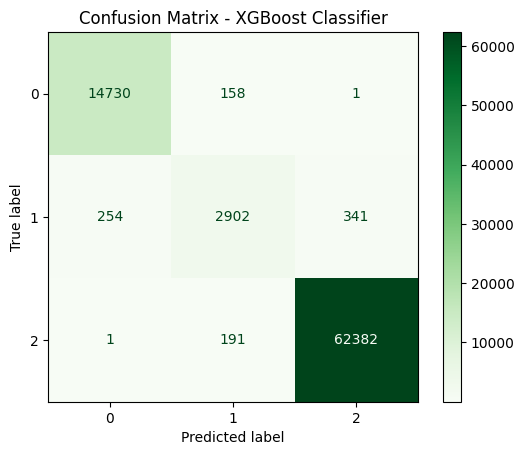

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99     14889
           1       0.89      0.83      0.86      3497
           2       0.99      1.00      1.00     62574

    accuracy                           0.99     80960
   macro avg       0.96      0.94      0.95     80960
weighted avg       0.99      0.99      0.99     80960



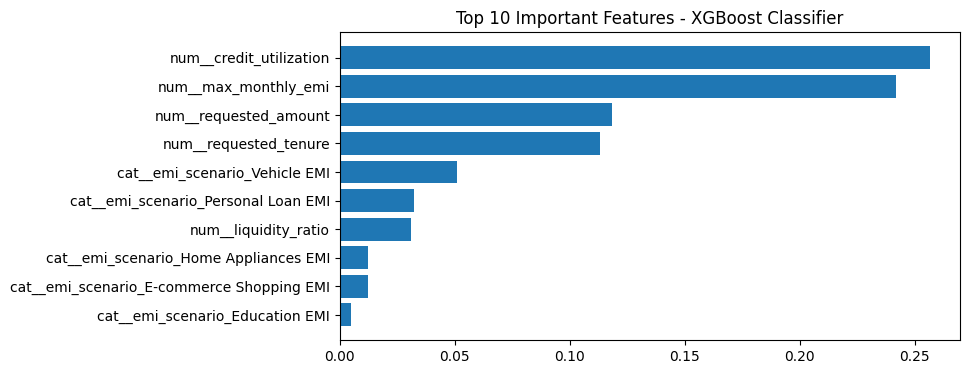

In [ ]:
# Evaluate XGBoost Classifier

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, preds_xgb_clf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Greens')
plt.title("Confusion Matrix - XGBoost Classifier")
plt.show()

print("Classification Report:\n", classification_report(y_test, preds_xgb_clf))

# Feature importance
xgb_model = xgb_clf.named_steps['model']
importances = xgb_model.feature_importances_
feat_names = preprocessor.get_feature_names_out()
imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=False).head(10)
plt.figure(figsize=(8,4))
plt.barh(imp_df['Feature'], imp_df['Importance'])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features - XGBoost Classifier")
plt.show()

### ➤ *Logistic Regression Model [Maximum EMI Prediction]*

In [ ]:
# Linear Regression Model (Regression)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

lin_reg = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lin_reg.fit(X_train, y_train)
preds_lin_reg = lin_reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds_lin_reg))
print("✅ Linear Regression Results")
print("RMSE:", round(rmse, 4))

✅ Linear Regression Results
RMSE: 0.5353


### ➤ *Logistic Regression Model [Maximum EMI Prediction] Evaluation*

RMSE: 0.5353 | R²: 0.5301


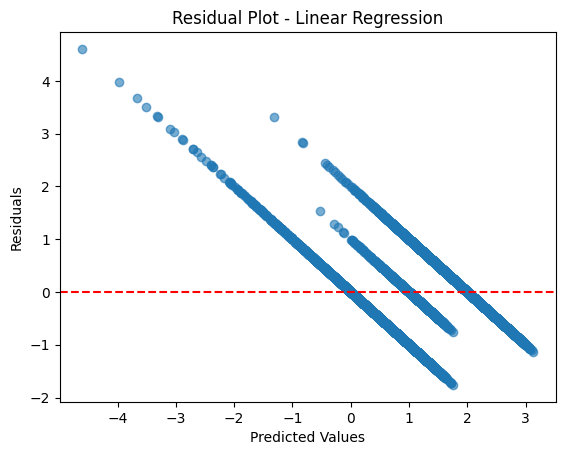

,Feature,Coefficient
15,num__requested_amount,0.267273
13,num__bank_balance,0.049079
57,cat__emi_scenario_Personal Loan EMI,0.047006
51,cat__house_type_Rented,0.040143
55,cat__emi_scenario_Education EMI,0.034511
18,num__existing_loans_flag,0.028775
14,num__emergency_fund,0.027271
7,num__college_fees,0.022598
6,num__school_fees,0.018186
22,num__loan_burden_score,0.015827


In [ ]:
# Evaluate Linear Regression Model

from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np # Import numpy for sqrt

rmse = np.sqrt(mean_squared_error(y_test, preds_lin_reg))
r2 = r2_score(y_test, preds_lin_reg)
print(f"RMSE: {rmse:.4f} | R²: {r2:.4f}")

# Residual plot
residuals = y_test - preds_lin_reg
plt.scatter(preds_lin_reg, residuals, alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - Linear Regression")
plt.show()

# Feature coefficients
feature_names = preprocessor.get_feature_names_out()
coef = lin_reg.named_steps['model'].coef_
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coef})
display(coef_df.sort_values('Coefficient', ascending=False).head(10))

### ➤ *Random Forest Regressor Model [Maximum EMI Prediction]*

In [ ]:
# Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.utils import resample
from sklearn.pipeline import Pipeline
import numpy as np, time

start = time.time()

# Downsample further for Colab stability
max_train_rows = 50000   # ↓ reduced from 100k
if len(X_train) > max_train_rows:
    X_train_sub, y_train_sub = resample(
        X_train, y_train,
        n_samples=max_train_rows,
        random_state=42
    )
    print(f"⚙️ Using {len(X_train_sub)} rows (from {len(X_train)}) for training.")
else:
    X_train_sub, y_train_sub = X_train, y_train

# Lightweight RandomForest configuration
rf_reg = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=40,        # ↓ from 80
        max_depth=10,           # shallower trees
        min_samples_split=4,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=42
    ))
])

print("Training Random Forest Regressor...")
rf_reg.fit(X_train_sub, y_train_sub)

preds_rf_reg = rf_reg.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, preds_rf_reg))

elapsed = round(time.time() - start, 2)
print(f"✅ Random Forest Regressor trained in {elapsed}s")
print("RMSE:", round(rmse, 4))

⚙️ Using 50000 rows (from 323840) for training.
Training Random Forest Regressor...
✅ Random Forest Regressor trained in 33.58s
RMSE: 0.1547


### ➤ *Random Forest Regressor Model [Maximum EMI Prediction] Evaluation*

RMSE: 0.1547 | R²: 0.9608


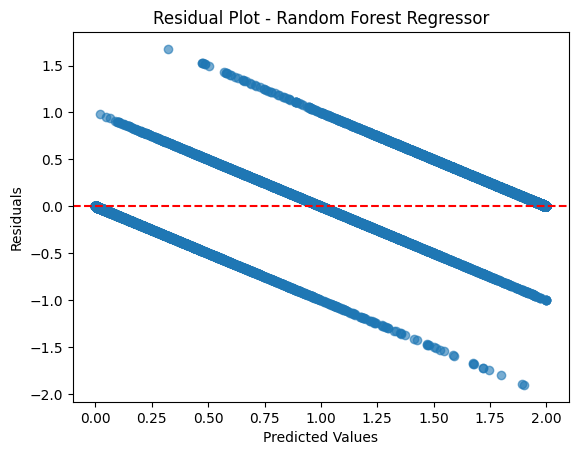

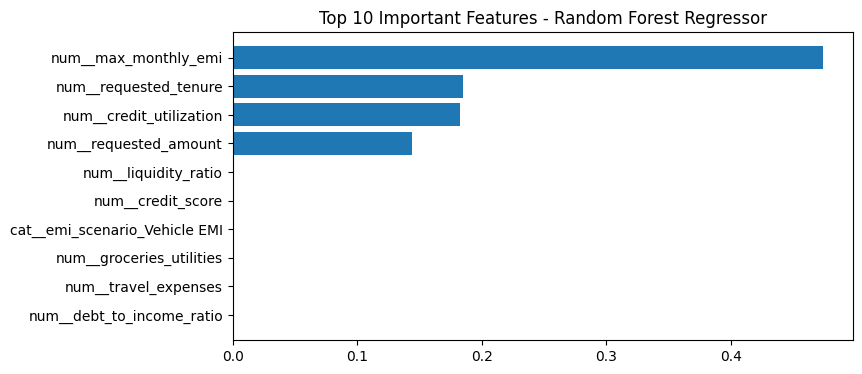

In [ ]:
# Evaluate Random Forest Regressor

from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np # Import numpy for sqrt

rmse = np.sqrt(mean_squared_error(y_test, preds_rf_reg))
r2 = r2_score(y_test, preds_rf_reg)
print(f"RMSE: {rmse:.4f} | R²: {r2:.4f}")

# Residual plot
residuals = y_test - preds_rf_reg
plt.scatter(preds_rf_reg, residuals, alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - Random Forest Regressor")
plt.show()

# Feature importance
rf_model = rf_reg.named_steps['model']
importances = rf_model.feature_importances_
feat_names = preprocessor.get_feature_names_out()
imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=False).head(10)
plt.figure(figsize=(8,4))
plt.barh(imp_df['Feature'], imp_df['Importance'])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features - Random Forest Regressor")
plt.show()

### ➤ *XGBoost Regressor Model [Maximum EMI Prediction]*

In [ ]:
# XGBoost Regressor (Regression)

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

xgb_reg = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(random_state=42))
])

xgb_reg.fit(X_train, y_train)
preds_xgb_reg = xgb_reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds_xgb_reg))
print("✅ XGBoost Regressor Results")
print("RMSE:", round(rmse, 4))

✅ XGBoost Regressor Results
RMSE: 0.1569


### ➤ *XGBoost Regressor Model [Maximum EMI Prediction] Evaluation*

RMSE: 0.1569 | R²: 0.9596


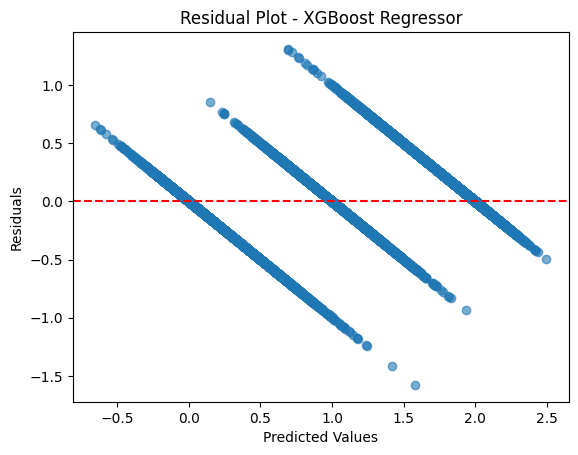

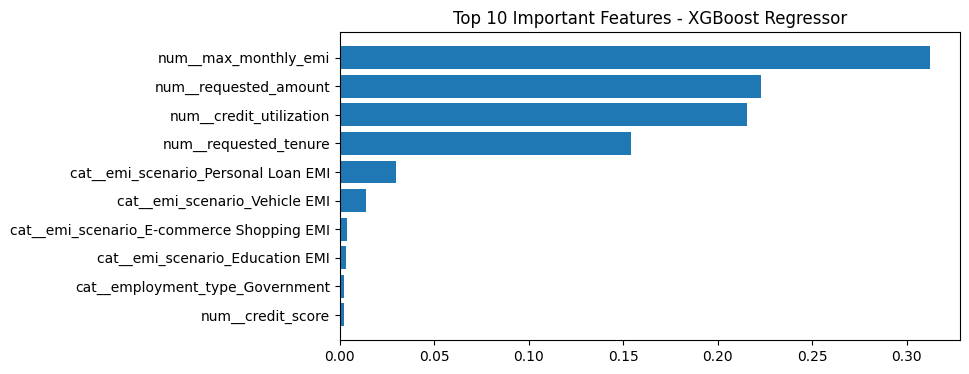

In [ ]:
# Evaluate XGBoost Regressor

from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np # Import numpy for sqrt

rmse = np.sqrt(mean_squared_error(y_test, preds_xgb_reg))
r2 = r2_score(y_test, preds_xgb_reg)
print(f"RMSE: {rmse:.4f} | R²: {r2:.4f}")

# Residual plot
residuals = y_test - preds_xgb_reg
plt.scatter(preds_xgb_reg, residuals, alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - XGBoost Regressor")
plt.show()

# Feature importance
xgb_model = xgb_reg.named_steps['model']
importances = xgb_model.feature_importances_
feat_names = preprocessor.get_feature_names_out()
imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=False).head(10)
plt.figure(figsize=(8,4))
plt.barh(imp_df['Feature'], imp_df['Importance'])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features - XGBoost Regressor")
plt.show()

### ➤ *Comparative Model Summary*

In [ ]:
# Comparative Model Performance Summary

import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error # Import necessary metrics
import numpy as np # Import numpy for sqrt

if is_classification:
    # Use predictions from classification models
    results_df = pd.DataFrame([
        ["Logistic Regression", accuracy_score(y_test, preds_log), f1_score(y_test, preds_log, average='weighted')],
        ["Random Forest Classifier", accuracy_score(y_test, preds_rf_clf), f1_score(y_test, preds_rf_clf, average='weighted')],
        ["XGBoost Classifier", accuracy_score(y_test, preds_xgb_clf), f1_score(y_test, preds_xgb_clf, average='weighted')]
    ], columns=["Model", "Accuracy", "F1 Score"])
else:
    # Use predictions from regression models
    results_df = pd.DataFrame([
        ["Linear Regression", np.sqrt(mean_squared_error(y_test, preds_lin_reg))],
        ["Random Forest Regressor", np.sqrt(mean_squared_error(y_test, preds_rf_reg))],
        ["XGBoost Regressor", np.sqrt(mean_squared_error(y_test, preds_xgb_reg))]
    ], columns=["Model", "RMSE"])

display(results_df)

,Model,Accuracy,F1 Score
0,Logistic Regression,0.923197,0.906513
1,Random Forest Classifier,0.925321,0.904502
2,XGBoost Classifier,0.988315,0.988115


### ➤ *Hyperparameter tuning with RandomizedSearchCV*

In [ ]:
# Manual Randomized Hyperparameter Search (fast and CV-safe)

from sklearn.model_selection import ParameterSampler, train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, mean_squared_error
from scipy.stats import randint
import numpy as np, joblib, time

try:
    start = time.time()

    # --- 1. Downsample for speed ---
    max_rows = 80000
    if len(X_train) > max_rows:
        X_tune, _, y_tune, _ = train_test_split(
            X_train, y_train, train_size=max_rows, random_state=42,
            stratify=y_train if is_classification else None
        )
        print(f"⚙️ Using {len(X_tune)} rows for hyperparameter tuning.")
    else:
        X_tune, y_tune = X_train, y_train

    # --- 2. Hold-out validation split ---
    X_tune_train, X_val, y_tune_train, y_val = train_test_split(
        X_tune, y_tune, test_size=0.2, random_state=42,
        stratify=y_tune if is_classification else None
    )

    # --- 3. Search space ---
    param_dist = {
        "n_estimators": randint(40, 80),
        "max_depth": randint(4, 8),
        "min_samples_split": randint(2, 5),
        "min_samples_leaf": randint(1, 3)
    }
    param_list = list(ParameterSampler(param_dist, n_iter=3, random_state=42))

    best_score = -np.inf
    best_params = None
    best_model = None

    # --- 4. Manual loop over parameter samples ---
    for i, params in enumerate(param_list, 1):
        print(f"⏳ Trial {i}/{len(param_list)} with {params}")

        model = (
            RandomForestClassifier(random_state=42, n_jobs=-1, **params)
            if is_classification
            else RandomForestRegressor(random_state=42, n_jobs=-1, **params)
        )

        pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
        pipe.fit(X_tune_train, y_tune_train)

        preds = pipe.predict(X_val)
        score = (
            accuracy_score(y_val, preds)
            if is_classification
            else -mean_squared_error(y_val, preds, squared=False)
        )

        print(f"   Score: {score:.4f}")

        if score > best_score:
            best_score = score
            best_params = params
            best_model = pipe

    # --- 5. Save best pipeline ---
    OUT_DIR.mkdir(exist_ok=True, parents=True)
    joblib.dump(best_model, OUT_DIR / "tuned_pipeline.joblib")

    print("\n✅ Tuned pipeline saved to:", OUT_DIR / "tuned_pipeline.joblib")
    print("Best parameters:", best_params)
    print(f"⏱ Completed in {time.time() - start:.2f} seconds.")

except Exception as e:
    print("⚠️ Hyperparameter search failed or skipped:", e)

⚙️ Using 80000 rows for hyperparameter tuning.
⏳ Trial 1/3 with {'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 54}
   Score: 0.8848
⏳ Trial 2/3 with {'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 60}
   Score: 0.8839
⏳ Trial 3/3 with {'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 62}
   Score: 0.8838

✅ Tuned pipeline saved to: /mnt/data/emipredict_artifacts/tuned_pipeline.joblib
Best parameters: {'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 54}
⏱ Completed in 20.29 seconds.


### ➤ *Evaluate each trained model*

In [ ]:
# Define and populate trained_pipelines dictionary

trained_pipelines = {
    "Logistic Regression": {"pipeline": log_clf, "preds": preds_log},
    "Random Forest Classifier": {"pipeline": rf_clf, "preds": preds_rf_clf},
    "XGBoost Classifier": {"pipeline": xgb_clf, "preds": preds_xgb_clf},
    "Linear Regression": {"pipeline": lin_reg, "preds": preds_lin_reg},
    "Random Forest Regressor": {"pipeline": rf_reg, "preds": preds_rf_reg},
    "XGBoost Regressor": {"pipeline": xgb_reg, "preds": preds_xgb_reg},
}

print("✅ Trained_pipelines dictionary created.")

✅ Trained_pipelines dictionary created.



Model: Logistic Regression
Accuracy: 0.9232 | F1: 0.9065
Classification report:
               precision    recall  f1-score   support

           0       0.85      0.90      0.87     14889
           1       0.31      0.04      0.07      3497
           2       0.94      0.98      0.96     62574

    accuracy                           0.92     80960
   macro avg       0.70      0.64      0.63     80960
weighted avg       0.90      0.92      0.91     80960



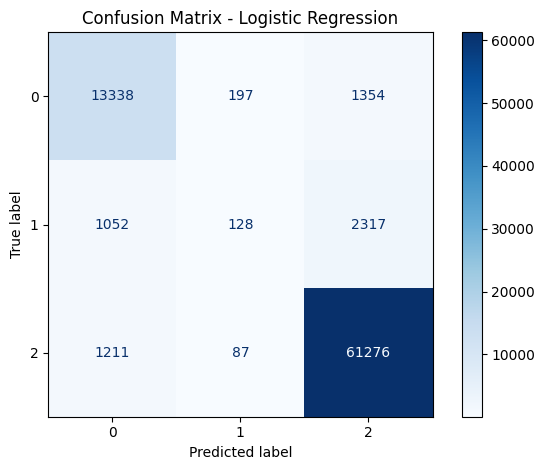

,Feature,Coef
15,num__requested_amount,-4.798270
17,num__max_monthly_emi,2.535772
16,num__requested_tenure,1.988446
58,cat__emi_scenario_Vehicle EMI,-0.754422
23,num__liquidity_ratio,0.571024
57,cat__emi_scenario_Personal Loan EMI,-0.538209
51,cat__house_type_Rented,-0.536174
53,cat__existing_loans_Yes,-0.496150
34,cat__marital_status_Married,-0.481067
35,cat__marital_status_Single,-0.467145



Model: Random Forest Classifier
Accuracy: 0.9253 | F1: 0.9045
Classification report:
               precision    recall  f1-score   support

           0       0.88      0.88      0.88     14889
           1       0.00      0.00      0.00      3497
           2       0.93      0.99      0.96     62574

    accuracy                           0.93     80960
   macro avg       0.61      0.62      0.61     80960
weighted avg       0.88      0.93      0.90     80960



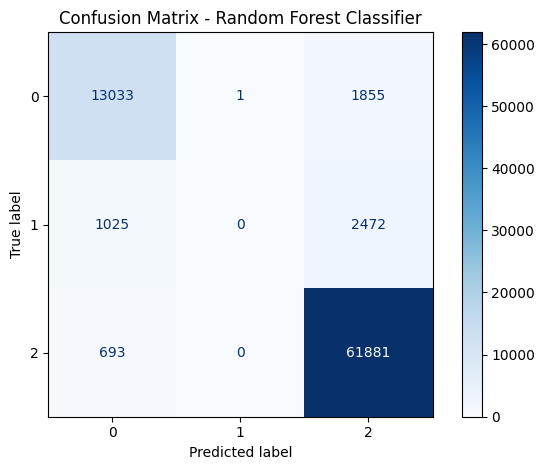

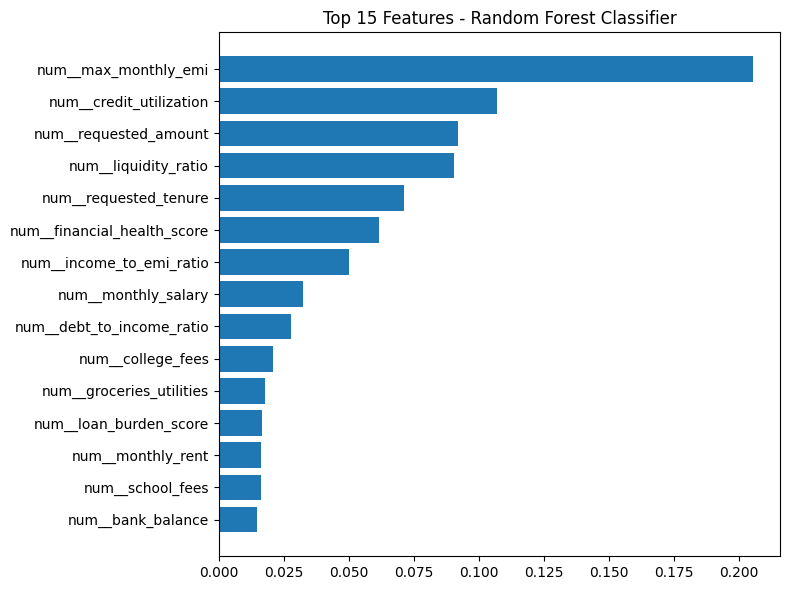


Model: XGBoost Classifier
Accuracy: 0.9883 | F1: 0.9881
Classification report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99     14889
           1       0.89      0.83      0.86      3497
           2       0.99      1.00      1.00     62574

    accuracy                           0.99     80960
   macro avg       0.96      0.94      0.95     80960
weighted avg       0.99      0.99      0.99     80960



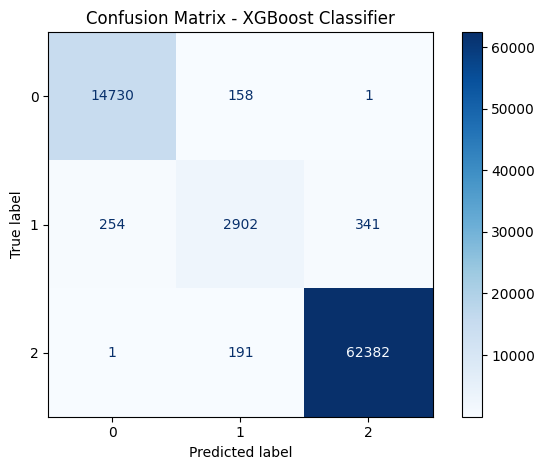

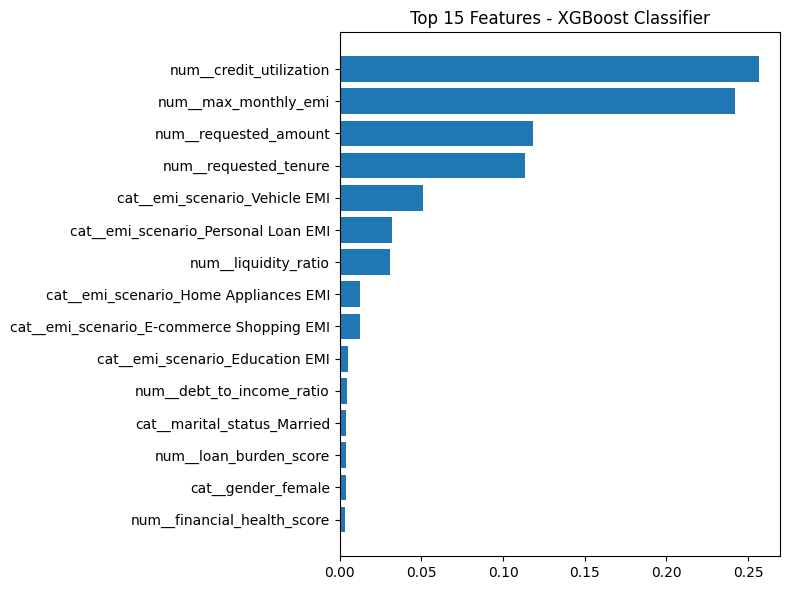

In [ ]:
# Per-model evaluation

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, f1_score, mean_squared_error, r2_score
import numpy as np

def evaluate_classification(pipeline, preds, model_name):
    print("\n==============================")
    print("Model:", model_name)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='weighted', zero_division=0)
    print(f"Accuracy: {acc:.4f} | F1: {f1:.4f}")
    print("Classification report:\n", classification_report(y_test, preds, zero_division=0))
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()

    # Feature importance or coefficients
    try:
        est = pipeline.named_steps["model"]
        feat_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
        if hasattr(est, "feature_importances_"):
            imp = est.feature_importances_
            imp_df = pd.DataFrame({"Feature": feat_names, "Importance": imp}).sort_values("Importance", ascending=False).head(15)
            plt.figure(figsize=(8,6))
            plt.barh(imp_df["Feature"][::-1], imp_df["Importance"][::-1])
            plt.title(f"Top 15 Features - {model_name}")
            plt.tight_layout()
            plt.show()
        elif hasattr(est, "coef_"):
            coef = est.coef_[0] if est.coef_.ndim>1 else est.coef_
            coef_df = pd.DataFrame({"Feature": feat_names, "Coef": coef}).sort_values("Coef", key=abs, ascending=False).head(15)
            display(coef_df)
    except Exception as e:
        print("Feature importance/coefs not available:", e)

def evaluate_regression(pipeline, preds, model_name):
    print("\n==============================")
    print("Model:", model_name)
    rmse = mean_squared_error(y_test, preds, squared=False)
    r2 = r2_score(y_test, preds)
    print(f"RMSE: {rmse:.4f} | R²: {r2:.4f}")
    residuals = y_test - preds
    plt.scatter(preds, residuals, alpha=0.6)
    plt.axhline(0, color='r', linestyle='--')
    plt.xlabel("Predicted")
    plt.ylabel("Residuals")
    plt.title(f"Residual Plot - {model_name}")
    plt.tight_layout()
    plt.show()

    try:
        est = pipeline.named_steps["model"]
        feat_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
        if hasattr(est, "feature_importances_"):
            imp = est.feature_importances_
            imp_df = pd.DataFrame({"Feature": feat_names, "Importance": imp}).sort_values("Importance", ascending=False).head(15)
            plt.figure(figsize=(8,6))
            plt.barh(imp_df["Feature"][::-1], imp_df["Importance"][::-1])
            plt.title(f"Top 15 Features - {model_name}")
            plt.tight_layout()
            plt.show()
        elif hasattr(est, "coef_"):
            coef = est.coef_
            coef_df = pd.DataFrame({"Feature": feat_names, "Coef": coef}).sort_values("Coef", key=abs, ascending=False).head(15)
            display(coef_df)
    except Exception as e:
        print("Feature importance/coefs not available:", e)

for name, entry in trained_pipelines.items():
    pipe = entry["pipeline"]
    preds = entry["preds"]
    if is_classification:
        # Check if the model is a classification model before evaluating
        if name in ["Logistic Regression", "Random Forest Classifier", "XGBoost Classifier"]:
            evaluate_classification(pipe, preds, name)
    else:
        # Check if the model is a regression model before evaluating
        if name in ["Linear Regression", "Random Forest Regressor", "XGBoost Regressor"]:
            evaluate_regression(pipe, preds, name)

### ➤ *SHAP Explainability*

In [ ]:
# Trained pipeline registry (for SHAP)
trained_pipelines = {}

if 'rf_reg' in locals() and 'preds_rf_reg' in locals():
    trained_pipelines["Random Forest Regressor"] = {"pipeline": rf_reg, "preds": preds_rf_reg}

if 'rf_clf' in locals() and 'preds_rf_clf' in locals():
    trained_pipelines["Random Forest Classifier"] = {"pipeline": rf_clf, "preds": preds_rf_clf}

if 'lin_reg' in locals() and 'preds_lin' in locals():
    trained_pipelines["Linear Regression"] = {"pipeline": lin_reg, "preds": preds_lin}

if 'log_clf' in locals() and 'preds_log' in locals():
    trained_pipelines["Logistic Regression"] = {"pipeline": log_clf, "preds": preds_log}

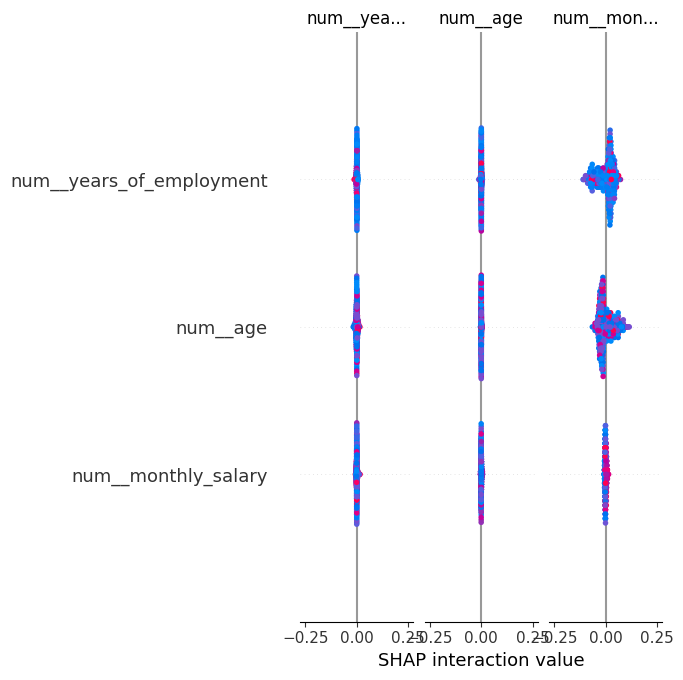

✅ Saved SHAP top features to: /mnt/data/emipredict_artifacts/shap_top_features.json


In [ ]:
# SHAP Explainability
try:
    import shap, numpy as np, json, matplotlib.pyplot as plt

    pipeline_for_shap = None
    if "XGBoost Classifier" in trained_pipelines:
        pipeline_for_shap = trained_pipelines["XGBoost Classifier"]["pipeline"]
    elif "Random Forest Classifier" in trained_pipelines:
        pipeline_for_shap = trained_pipelines["Random Forest Classifier"]["pipeline"]
    elif "Logistic Regression" in trained_pipelines:
        pipeline_for_shap = trained_pipelines["Logistic Regression"]["pipeline"]
    elif "Random Forest Regressor" in trained_pipelines:
        pipeline_for_shap = trained_pipelines["Random Forest Regressor"]["pipeline"]
    elif "Linear Regression" in trained_pipelines:
        pipeline_for_shap = trained_pipelines["Linear Regression"]["pipeline"]

    if pipeline_for_shap is None:
        print("No suitable pipeline for SHAP found.")
    else:
        pre = pipeline_for_shap.named_steps["preprocessor"]
        est = pipeline_for_shap.named_steps["model"]

        sample_X = X_train.sample(n=min(500, len(X_train)), random_state=42)
        X_trans = np.array(pre.transform(sample_X), dtype=np.float64)

        explainer = shap.TreeExplainer(est) if hasattr(est, "feature_importances_") else shap.KernelExplainer(est.predict, X_trans[:50])
        shap_values = explainer.shap_values(X_trans)

        feat_names = pre.get_feature_names_out()
        mean_abs = np.mean(np.abs(shap_values), axis=0) if not isinstance(shap_values, list) \
                   else np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
        top_idx = np.argsort(-mean_abs)[:30]
        top_feats = [feat_names[i] for i in top_idx]

        shap.summary_plot(shap_values, X_trans, feature_names=feat_names, show=True)

        (OUT_DIR / "shap_top_features.json").write_text(json.dumps(
            {"top_features": [str(x) for x in top_feats]}, indent=2
        ))
        print("✅ Saved SHAP top features to:", OUT_DIR / "shap_top_features.json")

except Exception as e:
    print("⚠️ SHAP not available or failed:", e)

### ➤ *Persist artifacts separately*

In [ ]:
# Define and populate trained_pipelines dictionary

trained_pipelines = {
    "Logistic Regression": {"pipeline": log_clf, "preds": preds_log},
    "Random Forest Classifier": {"pipeline": rf_clf, "preds": preds_rf_clf},
    "XGBoost Classifier": {"pipeline": xgb_clf, "preds": preds_xgb_clf},
    "Linear Regression": {"pipeline": lin_reg, "preds": preds_lin_reg},
    "Random Forest Regressor": {"pipeline": rf_reg, "preds": preds_rf_reg},
    "XGBoost Regressor": {"pipeline": xgb_reg, "preds": preds_xgb_reg},
}

print("✅ Trained_pipelines dictionary created.")

✅ Trained_pipelines dictionary created.


In [ ]:
# Save artifacts for production (preprocessor, estimator(s), feature_names, metadata)

# Save chosen best model: choose by metric (simple pick: if classification prefer model with highest F1)
best_model_name = None
if is_classification:
    best_row = results_df.sort_values("F1 Score", ascending=False).iloc[0]
    best_model_name = best_row["Model"]
else:
    best_row = results_df.sort_values("RMSE").iloc[0]
    best_model_name = best_row["Model"]

best_pipeline = trained_pipelines[best_model_name]["pipeline"]
# Save pipeline and components
joblib.dump(best_pipeline, OUT_DIR / "best_pipeline.joblib")
joblib.dump(best_pipeline.named_steps["preprocessor"], OUT_DIR / "preprocessor.joblib")
joblib.dump(best_pipeline.named_steps["model"], OUT_DIR / f"estimator_{best_model_name.replace(' ', '_')}.joblib")

# create feature_names.json
OUT_DIR.mkdir(exist_ok=True, parents=True)
try:
    pre = best_pipeline.named_steps.get("preprocessor", preprocessor)
    num_feats = numeric_cols
    cat_feats = []
    try:
        ohe = pre.named_transformers_["cat"].named_steps["onehot"]
        for col, cats in zip(categorical_cols, ohe.categories_):
            cat_feats += [f"{col}__{c}" for c in cats.tolist()]
    except Exception:
        cat_feats = categorical_cols
    feature_names = num_feats + cat_feats
except Exception as e:
    print("Feature name extraction fallback used:", e)
    feature_names = X_train.columns.tolist()

# Save category values for selectboxes
cat_values = {c: X[c].dropna().astype(str).value_counts().index.tolist()[:50] for c in categorical_cols}
(OUT_DIR / "category_values.json").write_text(json.dumps(cat_values, indent=2))

# metadata
metadata = {
    "target_col": target_col,
    "is_classification": bool(is_classification),
    "best_model": best_model_name,
    "trained_models": list(trained_pipelines.keys()),
    "numeric_cols": numeric_cols,
    "categorical_cols": categorical_cols,
    "label_mapping": label_mapping,
    "feature_names_path": str(OUT_DIR / "feature_names.json"),
    "preprocessor_path": str(OUT_DIR / "preprocessor.joblib"),
    "estimator_path": str(OUT_DIR / f"estimator_{best_model_name.replace(' ', '_')}.joblib"),
    "category_values_path": str(OUT_DIR / "category_values.json")
}
(META_PATH := OUT_DIR / "metadata.json").write_text(json.dumps(metadata, indent=2))
print(" ✅ Saved artifacts and metadata to", OUT_DIR)

 ✅ Saved artifacts and metadata to /mnt/data/emipredict_artifacts


### ➤ *MLflow logging*

In [ ]:
%pip install --quiet mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 99.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 774.7/774.7 kB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 12.6 MB/s eta 0:00:00


In [ ]:
# MLflow Logging (clean version)
try:
    import mlflow, mlflow.sklearn
    import numpy as np
    from sklearn.metrics import accuracy_score, f1_score, mean_squared_error, r2_score
    from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
    from sklearn.linear_model import LogisticRegression, LinearRegression
    from xgboost import XGBClassifier, XGBRegressor

    # Use a proper backend (SQLite)
    mlflow.set_tracking_uri("sqlite:///mlflow_tracking.db")
    mlflow.set_experiment("EMIPredict_Experiment")

    for name, entry in trained_pipelines.items():
        with mlflow.start_run(run_name=name):
            mlflow.log_param("model", name)
            mlflow.log_param("target", target_col)

            preds = entry["preds"]
            pipeline = entry["pipeline"]
            est = pipeline.named_steps["model"]

            if isinstance(est, (RandomForestClassifier, XGBClassifier, LogisticRegression)):
                mlflow.log_param("is_classification", True)
                mlflow.log_metric("accuracy", float(accuracy_score(y_test, preds)))
                mlflow.log_metric("f1_weighted", float(f1_score(y_test, preds, average='weighted', zero_division=0)))

            elif isinstance(est, (RandomForestRegressor, XGBRegressor, LinearRegression)):
                mlflow.log_param("is_classification", False)
                mse = mean_squared_error(y_test, preds)
                rmse = np.sqrt(mse)
                mlflow.log_metric("rmse", float(rmse))
                mlflow.log_metric("r2", float(r2_score(y_test, preds)))

    print("✅ MLflow logging completed successfully.")

except Exception as e:
    print("⚠️ MLflow not available or failed:", e)

2025/12/24 07:54:18 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2025/12/24 07:54:18 INFO mlflow.store.db.utils: Updating database tables
2025/12/24 07:54:19 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2025/12/24 07:54:19 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2025/12/24 07:54:19 INFO alembic.runtime.migration: Running upgrade  -> 451aebb31d03, add metric step
2025/12/24 07:54:19 INFO alembic.runtime.migration: Running upgrade 451aebb31d03 -> 90e64c465722, migrate user column to tags
2025/12/24 07:54:19 INFO alembic.runtime.migration: Running upgrade 90e64c465722 -> 181f10493468, allow nulls for metric values
2025/12/24 07:54:19 INFO alembic.runtime.migration: Running upgrade 181f10493468 -> df50e92ffc5e, Add Experiment Tags Table
2025/12/24 07:54:19 INFO alembic.runtime.migration: Running upgrade df50e92ffc5e -> 7ac759974ad8, Update run tags with larger limit
2025/12/24 07:54:19 INFO alembic.runtime.migration: Running 

✅ MLflow logging completed successfully.


### ➤ *Serving alignment check*

In [ ]:
# Header: Serving alignment test (sanity check for input compatibility)

import json, joblib, pandas as pd

raw_feat_file = OUT_DIR / "raw_feature_names.json"
best_pipe_file = OUT_DIR / "best_pipeline.joblib"

if raw_feat_file.exists() and best_pipe_file.exists():
    feat_names = json.loads(raw_feat_file.read_text())["raw_features"]
    X_zero = pd.DataFrame([{f: 0 for f in feat_names}])
    try:
        bp = joblib.load(best_pipe_file)
        pred = bp.predict(X_zero)
        print("✅ Sanity predict succeeded. Example output:", pred[:5])
    except Exception as e:
        print("❌ Sanity predict failed. Error:", e)
else:
    print("⚠️ raw_feature_names.json or best_pipeline.joblib missing. Run preprocessing & model training cells first.")

✅ Sanity predict succeeded. Example output: [2]


### ➤ *Generate production-safe Streamlit app file*

In [ ]:
# Header: Generate Streamlit app (reads metadata and feature_names)

app_code = f'''
import streamlit as st, joblib, json
import pandas as pd
from pathlib import Path

st.set_page_config(page_title="EMIPredict AI", layout="centered")
st.title("EMIPredict AI — EMI Risk Predictor")

OUT_DIR = Path("{OUT_DIR}")
meta_path = OUT_DIR / "metadata.json"
features_path = OUT_DIR / "feature_names.json"
cat_values_path = OUT_DIR / "category_values.json"
best_pipeline_path = OUT_DIR / "best_pipeline.joblib"

if not meta_path.exists():
    st.error("metadata.json missing. Run training notebook.")
    st.stop()

meta = json.loads(meta_path.read_text())
feature_names = json.loads(features_path.read_text()).get("feature_names", [])
numeric_cols = meta.get("numeric_cols", [])
categorical_cols = meta.get("categorical_cols", [])

# Load pipeline
if best_pipeline_path.exists():
    pipeline = joblib.load(best_pipeline_path)
else:
    st.error("Best pipeline missing. Ensure training completed.")
    st.stop()

st.subheader("Enter borrower data")
input_data = {{}}
cols = st.columns(2)
for i, col in enumerate(numeric_cols):
    with cols[i % 2]:
        input_data[col] = st.number_input(col, value=0.0, format="%.2f")
for i, col in enumerate(categorical_cols):
    with cols[(i + len(numeric_cols)) % 2]:
        options = None
        if cat_values_path.exists():
            cat_map = json.loads(cat_values_path.read_text())
            options = cat_map.get(col, None)
        if options:
            input_data[col] = st.selectbox(col, options)
        else:
            input_data[col] = st.text_input(col, value="")

if st.button("Predict"):
    X = pd.DataFrame([input_data])
    try:
        pred = pipeline.predict(X)
        label_map = meta.get("label_mapping", None)
        if meta.get("is_classification", True) and label_map:
            rev = {{int(v):k for k,v in label_map.items()}}
            st.write("Prediction:", rev.get(int(pred[0]), pred[0]))
        else:
            st.write("Prediction:", pred[0])
    except Exception as e:
        st.error("Prediction failed. Error: " + str(e))
'''
app_file = Path("/mnt/data/emipredict_streamlit_app.py")
app_file.write_text(app_code)
print(" ✅ Wrote Streamlit app to:", app_file)

 ✅ Wrote Streamlit app to: /mnt/data/emipredict_streamlit_app.py


### ➤ *Create pinned requirements.txt*

In [ ]:
# Header: Create requirements (pinned minimal versions)

reqs = [
    "pandas>=1.3.0",
    "numpy>=1.21.0",
    "scikit-learn>=1.0.0",
    "joblib>=1.1.0",
    "streamlit>=1.10.0",
    "xgboost>=1.6.0",
    "mlflow>=1.30.0",
    "shap>=0.41.0"
]
Path("/mnt/data/emipredict_requirements.txt").write_text("\n".join(reqs))
print(" ✅ Requirements saved to /mnt/data/emipredict_requirements.txt")

 ✅ Requirements saved to /mnt/data/emipredict_requirements.txt


### ➤ *Final artifact list & notes*

In [ ]:
# Header: Sanity list of artifacts

print("Artifacts in OUT_DIR:")
for p in sorted(OUT_DIR.glob("*")):
    print("-", p.name, "-", p.stat().st_size, "bytes")
print("\nStreamlit app path: /mnt/data/emipredict_streamlit_app.py")
print("Run app locally: streamlit run /mnt/data/emipredict_streamlit_app.py")

Artifacts in OUT_DIR:
- baseline_pipeline.joblib - 6749640 bytes
- best_pipeline.joblib - 1317262 bytes
- category_values.json - 900 bytes
- estimator_XGBoost_Classifier.joblib - 1308837 bytes
- feature_names.json - 2153 bytes
- metadata.json - 1582 bytes
- preprocessor.joblib - 8406 bytes
- raw_feature_names.json - 848 bytes
- shap_top_features.json - 2096 bytes
- tuned_pipeline.joblib - 636003 bytes

Streamlit app path: /mnt/data/emipredict_streamlit_app.py
Run app locally: streamlit run /mnt/data/emipredict_streamlit_app.py
